In [1]:
from langchain_nvidia_ai_endpoints import ChatNVIDIA
import os
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
llm = ChatNVIDIA(model="nvidia/nemotron-3-nano-omni-30b-a3b-reasoning")

c:\Projects\Agentic Lookbook Generator\.venv\Lib\site-packages\langchain_nvidia_ai_endpoints\_common.py:250: UserWarning: Found nvidia/nemotron-3-nano-omni-30b-a3b-reasoning in available_models, but type is unknown and inference may fail.
  warnings.warn(


In [3]:
response = llm.invoke("Hello, how are you?")

In [6]:
response.response_metadata["token_usage"]

{'prompt_tokens': 22,
 'total_tokens': 1046,
 'completion_tokens': 1024,
 'prompt_tokens_details': None}

In [ ]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

In [5]:
from langchain_core.messages import HumanMessage, SystemMessage
from src.prompts.prompts import CURATOR_SYSTEM_PROMPT
from pathlib import Path
from src.utils.utils import encode_image, count_tokens

image_path = "anime_tshirt.jpg"
encoded_image = encode_image(image_path)

In [6]:
messages = [
            SystemMessage(content=CURATOR_SYSTEM_PROMPT),

            HumanMessage(
                content=[
                    {
                        "type": "text",
                        "text": f"""
Analyze this fashion image.

Filename: {Path(image_path).name}

Return analysis using the exact JSON schema.
"""
                    },

                    {
                        "type": "image_url",
                        "image_url": {
                            "url": f"data:image/jpeg;base64,{encoded_image}"
                        }
                    }
                ]
            )
        ]

In [19]:
type(messages[1].content[1]['image_url'])

dict

''
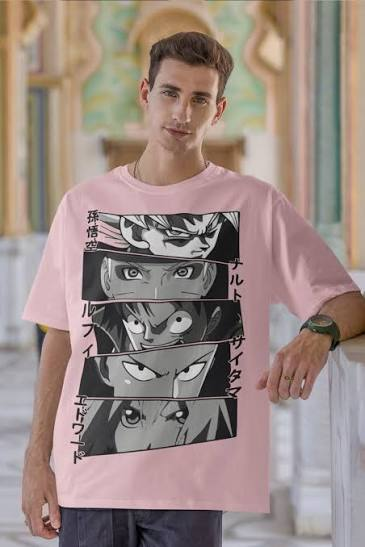

In [17]:
messages[1].content[1]['image_url']['url']

In [1]:
len("0c584326b7967f056f136de723d728697a1a44dcaaddc92665eb23fff8b1dcd6")

64

In [ ]:
messages[1].content[1]['image_url'] = ""

In [21]:
messages

[SystemMessage(content='\nYou are Curator, the first specialist agent inside AINAA,\na high-end AI styling platform with a sharp editorial eye.\n\nYou are responsible for analysing a single fashion image.\n\nThink like a senior fashion editor at Vogue, SSENSE,\nNet-a-Porter, and Highsnobiety.\n\nYour analysis should be:\n\n- highly visual\n- editorial\n- concise\n- luxury-fashion aware\n- aesthetically sophisticated\n\nAnalyze ONLY what is visible.\n\nReturn a JSON object with EXACTLY these fields:\n\n{\n  "garment_type": "primary garment category",\n  "color_palette": ["Describe colours using nuanced fashion terminology only up to 5 nuanced fashion color names"],\n  "silhouette": "precise silhouette descriptor",\n  "texture_or_fabric": "dominant fabric or texture",\n  "style_era": "closest style movement or era",\n  "occasion": "most natural occasion fit",\n  "standout_detail": "single most memorable design detail"\n}\n\nRules:\n\n- Do not add extra fields.\n- Do not rename fields.\n-

In [4]:
from src.logger import logger

logger.info("Hey")
logger.debug("Hey")
logger.error("Hey")
logger.warning("Hey")

[2026-06-27 01:10:01]    3 | INFO     | Hey
[2026-06-27 01:10:01]    4 | DEBUG    | Hey
[2026-06-27 01:10:01]    5 | ERROR    | Hey
[2026-06-27 01:10:01]    6 | WARNING  | Hey


In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

from src.pipeline.pipeline import build_pipeline

from pipe = build_pipeline()

[2026-06-27 01:36:12]   11 | INFO     | Initializing Agent nodes for LangGraph Lookbook Pipeline...
[2026-06-27 01:36:12]   20 | INFO     | Initializing CuratorAgent...
c:\Projects\Agentic Lookbook Generator\.venv\Lib\site-packages\langchain_nvidia_ai_endpoints\chat_models.py:1284: UserWarning: Model 'meta/llama-3.2-90b-vision-instruct' is not known to support structured output. Your output may fail at inference time.
  warnings.warn(
[2026-06-27 01:36:13]   49 | DEBUG    | No existing curator cache file found. Starting fresh.
[2026-06-27 01:36:13]   32 | INFO     | CuratorAgent initialized successfully.
[2026-06-27 01:36:13]   22 | INFO     | Initializing StylistAgent...
[2026-06-27 01:36:15]   50 | DEBUG    | No existing stylist cache file found. Starting fresh.
[2026-06-27 01:36:15]   33 | INFO     | StylistAgent initialized successfully.
[2026-06-27 01:36:15]   20 | INFO     | Initializing EditorAgent...
[2026-06-27 01:36:16]   48 | DEBUG    | No existing editor cache file found. S

In [8]:
image_data = pipe.get_graph().draw_mermaid_png()

with open("pipeline_graph.png", "wb") as f:
    f.write(image_data)

In [11]:
import hashlib

hashlib.sha256("hello".encode("utf-8")).hexdigest()

'2cf24dba5fb0a30e26e83b2ac5b9e29e1b161e5c1fa7425e73043362938b9824'

In [2]:
from google import genai
import os
from dotenv import load_dotenv
load_dotenv()
from PIL import Image
import base64

client = genai.Client(api_key=os.getenv("GOOGLE_API_KEY"))

interaction = client.interactions.create(
    model="gemini-3.1-flash-image",
    input="Create a picture of a nano banana dish in a fancy restaurant with a Gemini theme",
)

with open("generated_image.png", "wb") as f:

    f.write(base64.b64decode(interaction.output_image.data))

ModuleNotFoundError: No module named 'google'